# Experiment 03 - 48h run detail (8 probes x 10 sites)

`run_20260612_48h` (2026-06-14 19:25 -> 2026-06-16 19:16 PKT, two days). One idea per
graph, all times PKT, **mean** used for averages. Data is read from the **normalized**
star-schema CSVs (`dim_*`/`fact_*`, written by `trace_monitor.py`) and joined here, so
probe labels (`isp.city (ASN)`) and site names come straight from the `dim_*` tables -
no relabelling in the notebook. Probes are **grouped by city** where it helps compare
ISPs. Companion to `findings/03_longitudinal_routing_48h.md`.

In [23]:
import math, itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates, matplotlib.patches as mpatches

RUN_DIR = '../experiments/03_longitudinal_routing/results/run_20260612_48h'
NORM = RUN_DIR + '/normalized'

# Read the normalized star schema (written by trace_monitor.py) and join to flat frames.
# dim_probe already carries the clean label 'isp.city (ASN)' + city, so there is no
# relabelling here - this notebook only reads the data, it does not define probe identity.
dim_probe = pd.read_csv(f'{NORM}/dim_probe.csv')
dim_site  = pd.read_csv(f'{NORM}/dim_site.csv')
df = (pd.read_csv(f'{NORM}/fact_trace.csv')
        .merge(dim_probe, on='probe_id', how='left').merge(dim_site, on='site_id', how='left')
        .rename(columns={'label': 'probe', 'probe_asn_measured': 'probe_asn', 'asn_registered': 'probe_asn_reg'}))
pg = (pd.read_csv(f'{NORM}/fact_ping.csv')
        .merge(dim_probe, on='probe_id', how='left').merge(dim_site, on='site_id', how='left')
        .rename(columns={'label': 'probe'}))

def to_pkt(col):  # UTC -> naive PKT (UTC+5) so axes label in local time
    return pd.to_datetime(col).dt.tz_convert('Asia/Karachi').dt.tz_localize(None)
df['t'] = to_pkt(df['trace_time']); df['hr'] = df['t'].dt.floor('h'); df['hour'] = df['t'].dt.hour
ok = df[df['destination_responded']]
pg['t'] = to_pkt(pg['ping_time'])

# clean names + city come straight from dim_probe; only the city *ordering* is a choice
CITY_NAME  = dict(zip(dim_probe['city_code'], dim_probe['city']))
CITY_ORDER = ['isb', 'lhe', 'hrp', 'khi']          # group probes by city in this order
_ck = {c: i for i, c in enumerate(CITY_ORDER)}
PROBES   = (dim_probe.assign(_k=dim_probe['city_code'].map(_ck).fillna(99))
                     .sort_values(['_k', 'isp'])['label'].tolist())
PROBE_CC = dict(zip(dim_probe['label'], dim_probe['city_code']))

def time_heatmap(matrix, title, cmap, vmin, vmax):
    cols = list(matrix.columns); x0, x1 = mdates.date2num(cols[0]), mdates.date2num(cols[-1])
    fig, ax = plt.subplots(figsize=(14, 0.45 * len(matrix.index) + 1.6))
    im = ax.imshow(matrix.values, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   extent=[x0, x1, len(matrix.index), 0], interpolation='nearest')
    ax.set_yticks([i + 0.5 for i in range(len(matrix.index))]); ax.set_yticklabels(matrix.index, fontsize=8)
    ax.xaxis_date(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d %H:%M')); ax.tick_params(axis='x', labelsize=8)
    ax.set_title(title, fontsize=11)
    return fig, ax, im

# city coordinates (for the theoretical-latency graph)
CITY_COORD = {
    'Islamabad': (33.69, 73.06), 'Lahore': (31.55, 74.34), 'Karachi': (24.86, 67.01), 'Haripur': (33.99, 72.93),
    'Singapore': (1.35, 103.82), 'Secaucus': (40.79, -74.06), 'New Jersey': (40.79, -74.06),
    'New York': (40.71, -74.01), 'Brooklyn': (40.65, -73.95), 'Tempe': (33.43, -111.94),
    'Cologne': (50.94, 6.96), 'Frankfurt': (50.11, 8.68), 'London': (51.51, -0.13),
    'Marseille': (43.30, 5.37), 'Gebze': (40.80, 29.44), 'Istanbul': (41.01, 28.98), 'Muscat': (23.59, 58.41),
}
def coord_of(loc):
    if not isinstance(loc, str): return None
    for name, c in CITY_COORD.items():
        if name in loc: return c
    return None
def probe_coord(label):
    cc = PROBE_CC.get(label); return CITY_COORD.get(CITY_NAME.get(cc, '')) if cc else None
def haversine_km(a, b):
    Re = 6371.0; la1, lo1, la2, lo2 = map(math.radians, [a[0], a[1], b[0], b[1]])
    h = math.sin((la2-la1)/2)**2 + math.cos(la1)*math.cos(la2)*math.sin((lo2-lo1)/2)**2
    return 2*Re*math.asin(math.sqrt(h))
def theo_rtt_ms(km): return 2.0 * km / 200000.0 * 1000.0   # fibre ~ 2/3 c

print('trace rounds:', len(df), '| probes:', len(PROBES), '| sites:', df['target_label'].nunique())
print('probes (city-grouped):', PROBES)
print('span PKT:', df['t'].min(), '->', df['t'].max())

trace rounds: 14319 | probes: 8 | sites: 10
probes (city-grouped): ['nayatel.isb (AS23674)', 'nova.lhe (AS136174)', 'ptcl.lhe (AS17557)', 'transworld.lhe (AS38193)', 'zcom.lhe (AS152605)', 'cybernet.hrp (AS9541)', 'cybernet.khi (AS9541)', 'ptcl.khi (AS17557)']
span PKT: 2026-06-14 19:25:33 -> 2026-06-16 19:16:46


## 1. Which sites reply at all?

Red = 0%: those firewall ICMP at the host (the traceroute still reaches their network),
so they are blocked, not down.

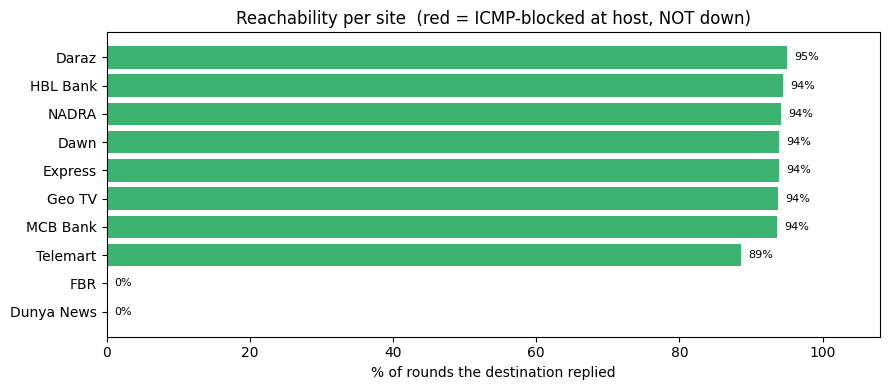

In [24]:
reach = (df.groupby('target_label')['destination_responded'].mean() * 100).sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(reach.index, reach.values, color=['tomato' if v == 0 else 'mediumseagreen' for v in reach.values])
for i, v in enumerate(reach.values): ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=8)
ax.set_xlim(0, 108); ax.set_xlabel('% of rounds the destination replied')
ax.set_title('Reachability per site  (red = ICMP-blocked at host, NOT down)')
plt.tight_layout(); plt.show()

## 2. Outage: which probe went dark, and when

Green = up that hour, red = produced nothing (ISP down). One red band = the whole
story. Exact window printed below.

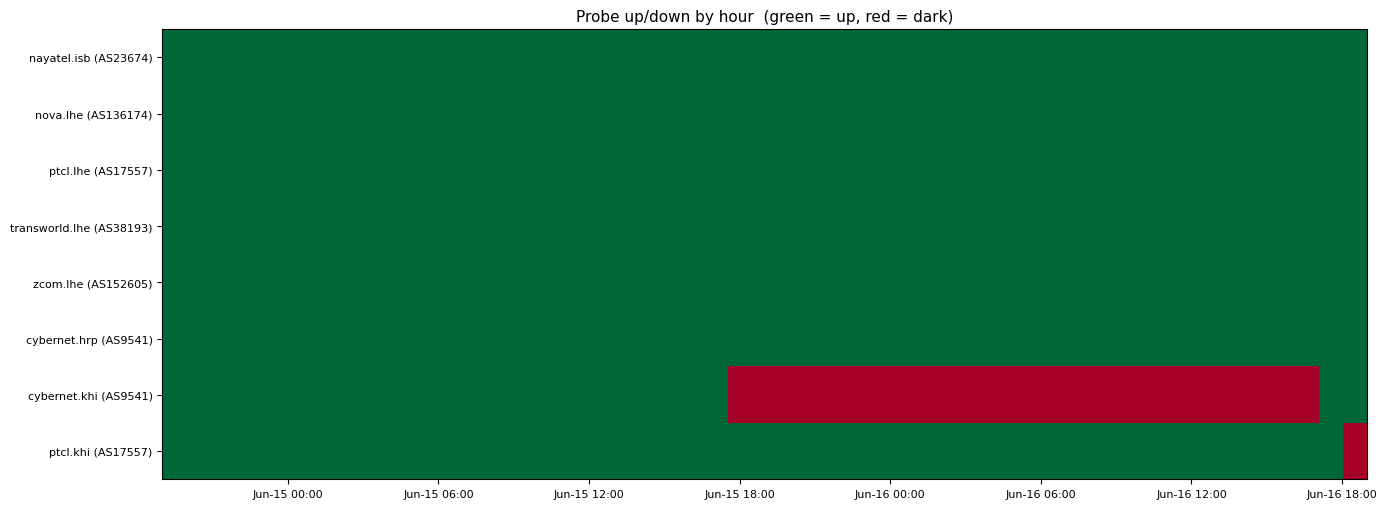

Outage windows (gap > 25 min):
  cybernet.khi (AS9541)    DOWN Jun-15 17:26 -> UP Jun-16 18:58 PKT  (25.5 h)


In [25]:
ct = df.groupby(['probe', 'hr']).size().unstack('hr').reindex(index=PROBES)
live = (ct.fillna(0) > 0).astype(int)
fig, ax, im = time_heatmap(live, 'Probe up/down by hour  (green = up, red = dark)', 'RdYlGn', 0, 1)
plt.tight_layout(); plt.show()

print('Outage windows (gap > 25 min):')
found = False
for probe, g in df.groupby('probe'):
    tps = g['t'].sort_values().drop_duplicates().reset_index(drop=True)
    for i in range(1, len(tps)):
        d = (tps[i] - tps[i-1]).total_seconds() / 60
        if d > 25:
            found = True
            print(f'  {probe:<24} DOWN {tps[i-1]:%b-%d %H:%M} -> UP {tps[i]:%b-%d %H:%M} PKT  ({d/60:.1f} h)')
if not found: print('  none')

## 3. Which sites were reachable, by hour

A row red the whole time = ICMP-blocked (Dunya, FBR). A row that turns red only for a
stretch would be a real site outage (there were none).

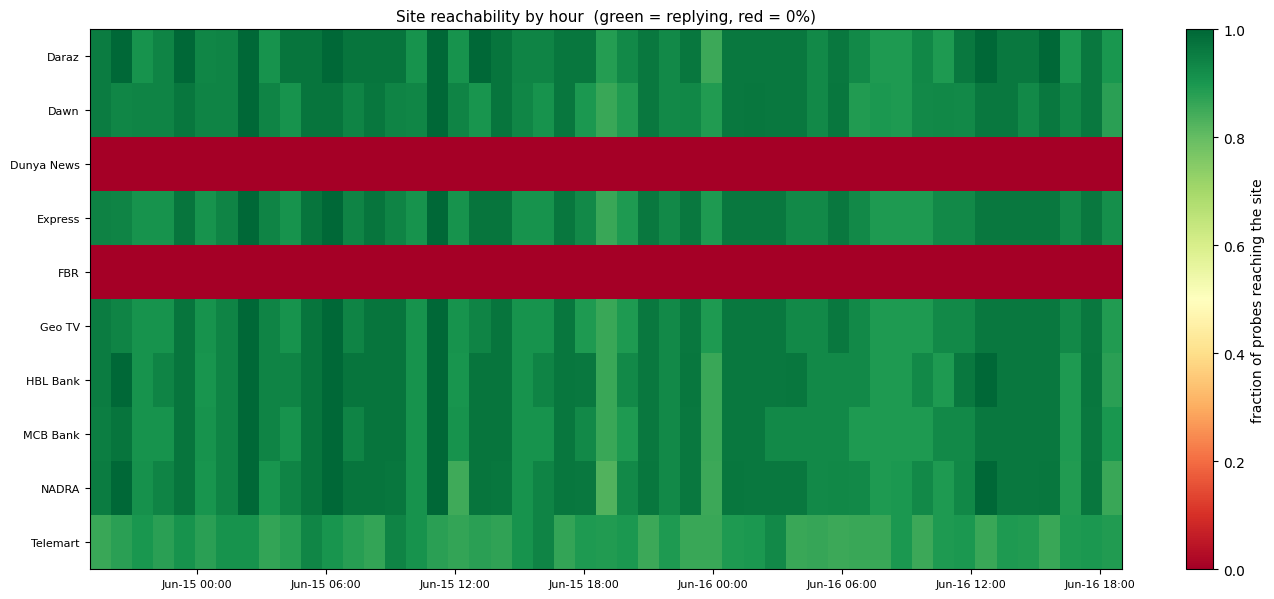

In [26]:
rr = df.groupby(['hr', 'target_label'])['destination_responded'].mean().unstack('target_label').T
fig, ax, im = time_heatmap(rr, 'Site reachability by hour  (green = replying, red = 0%)', 'RdYlGn', 0, 1)
plt.colorbar(im, ax=ax, label='fraction of probes reaching the site'); plt.tight_layout(); plt.show()

## 4. Mean latency by site and ISP (probes grouped by city)

Darker = slower. **Probes are grouped by city** (white separators + city labels on top),
so each block is "the ISPs available to a customer in that city." Within a block you
can see how differently each ISP serves the same site - e.g. in Lahore, Transworld /
Z-Com reach Cloudflare in ~20 ms while PTCL takes 130+ ms.

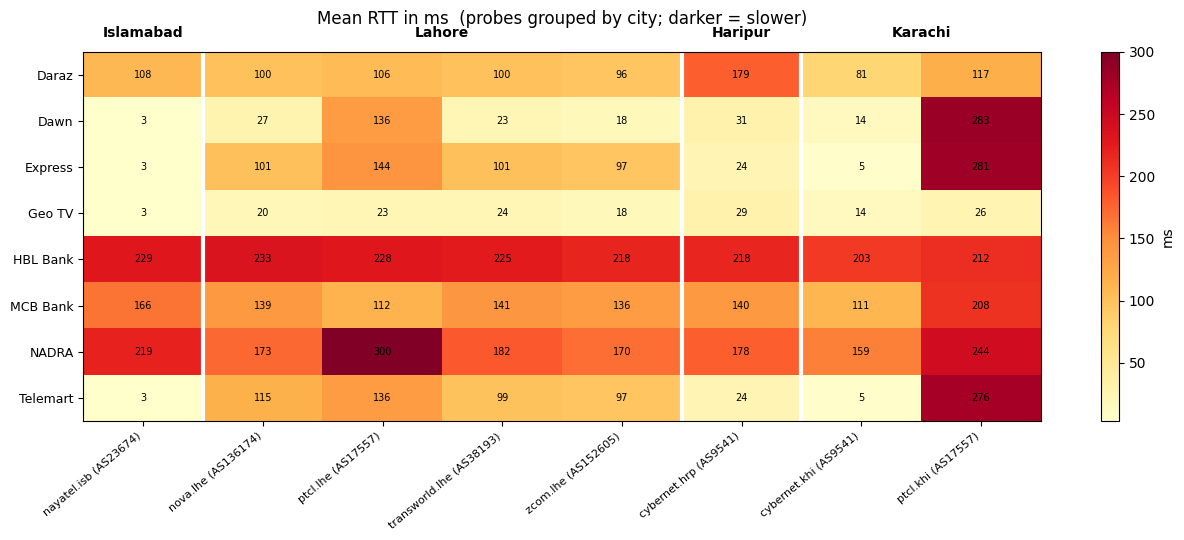

In [27]:
piv = ok.pivot_table(index='target_label', columns='probe', values='dest_rtt_ms', aggfunc='mean').reindex(columns=PROBES)
fig, ax = plt.subplots(figsize=(13, 5.5))
im = ax.imshow(piv.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index, fontsize=9)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if pd.notna(v): ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7)
# group columns by city: white separators + a city-name band on top
codes = [PROBE_CC[p] for p in piv.columns]; pos = 0
for code, grp in itertools.groupby(codes):
    n = len(list(grp))
    if pos > 0: ax.axvline(pos - 0.5, color='white', lw=3)
    ax.text(pos + n/2 - 0.5, -0.75, CITY_NAME[code], ha='center', va='bottom', fontsize=10, fontweight='bold')
    pos += n
ax.set_title('Mean RTT in ms  (probes grouped by city; darker = slower)', pad=20)
plt.colorbar(im, ax=ax, label='ms'); plt.tight_layout(); plt.show()

## 5. CDN serving-city flips (one graph per site)

Rows are probes, x is time, **each colour is a city** the CDN served from. A row that
changes colour = the serving edge flipped. NADRA (Akamai) and MCB (Sucuri) move a lot.
A **grey** row = reached the dest but no geolocatable handoff hop, i.e. the probe
**peers directly** with the CDN (e.g. Transworld straight into Akamai/Sucuri).

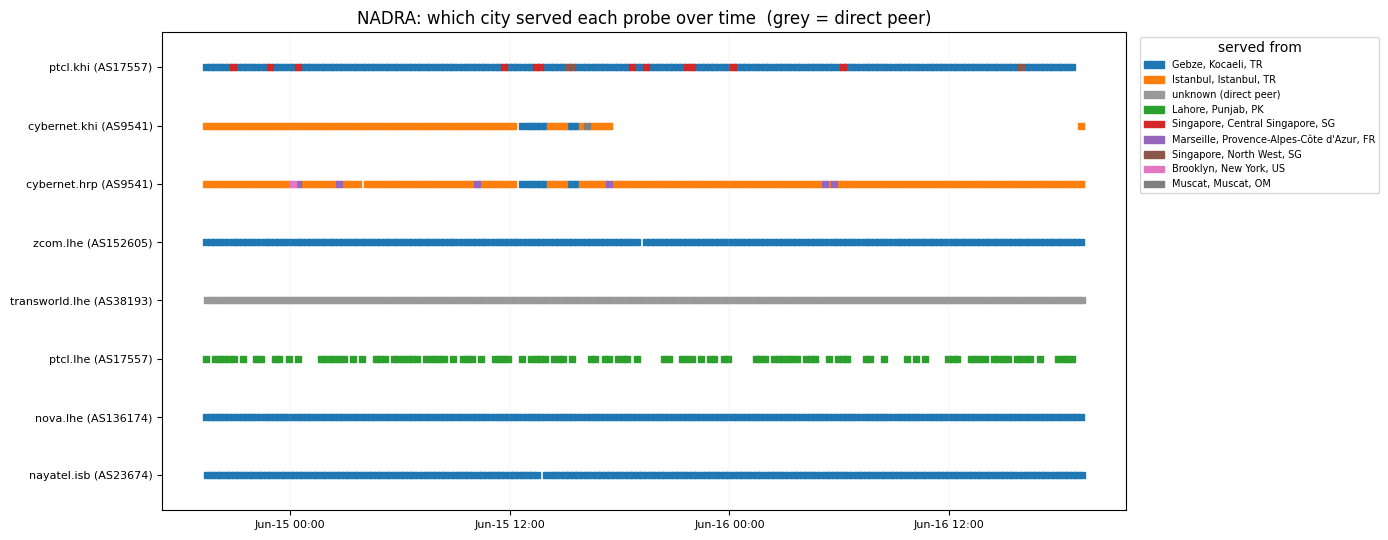

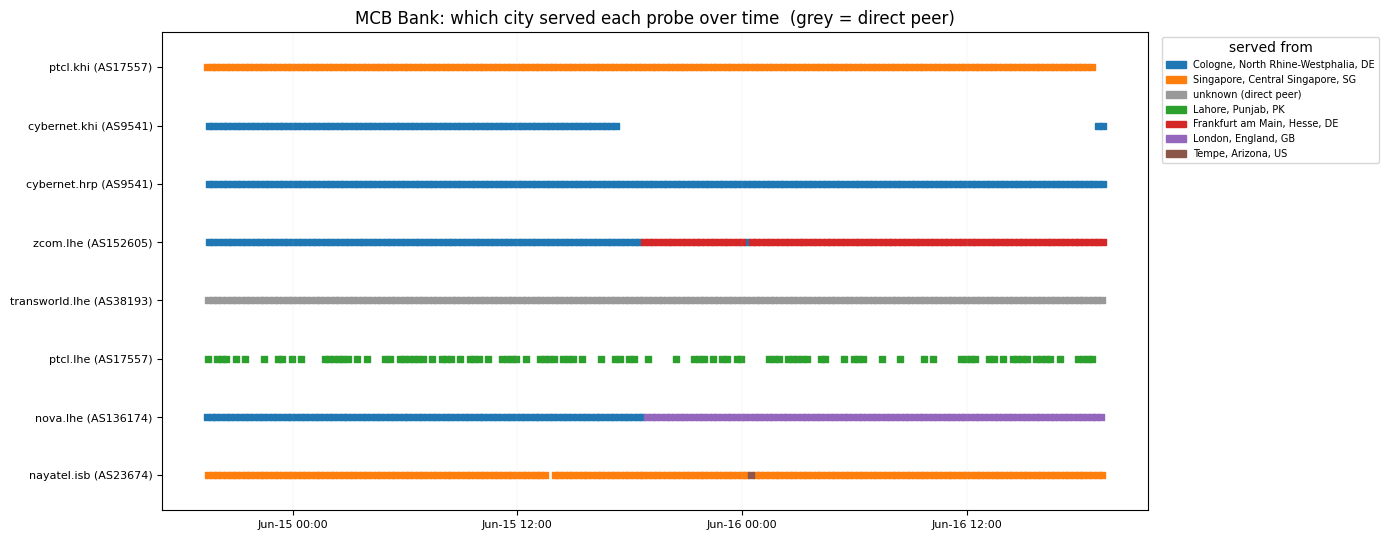

In [28]:
def metro_timeline(site):
    g = ok[ok['target_label'] == site].copy()
    g['loc'] = g['dest_location'].fillna('unknown (direct peer)')
    metros = g['loc'].value_counts().index.tolist()
    real = [m for m in metros if m != 'unknown (direct peer)']
    cmap = plt.get_cmap('tab10'); cidx = {m: i for i, m in enumerate(real)}; yidx = {p: i for i, p in enumerate(PROBES)}
    def colour(m): return '0.6' if m == 'unknown (direct peer)' else cmap(cidx[m] % 10)
    fig, ax = plt.subplots(figsize=(14, 0.5 * len(PROBES) + 1.5))
    for m in metros:
        s = g[g['loc'] == m]
        ax.scatter(s['t'], s['probe'].map(yidx), marker='s', s=16, color=colour(m))
    ax.set_yticks(range(len(PROBES))); ax.set_yticklabels(PROBES, fontsize=8); ax.set_ylim(-0.6, len(PROBES) - 0.4)
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 12)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d %H:%M')); ax.tick_params(axis='x', labelsize=8)
    ax.grid(True, axis='x', lw=0.3, alpha=0.3)
    handles = [mpatches.Patch(color=colour(m), label=m) for m in metros]
    ax.legend(handles=handles, fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left', title='served from')
    ax.set_title(f'{site}: which city served each probe over time  (grey = direct peer)')
    plt.tight_layout(); plt.show()

metro_timeline('NADRA')
metro_timeline('MCB Bank')

## 5b. Cloudflare: where each ISP hands off, and how they compare

The Cloudflare-fronted sites are **anycast** - the same hostname is served from whichever
edge the probe's ISP hands off to - so this isolates pure **CDN peering quality**. The
grid shows mean RTT to Cloudflare per ISP, annotated with the **handoff city** (where the
probe enters Cloudflare's network); a local handoff (Karachi/Lahore/Islamabad) at a few
ms vs a foreign one (Singapore/Paris etc.) at 100 ms+ for identical content is the whole
story. The table then shows **who hands each ISP off into Cloudflare** (the AS just before
AS13335): a direct peering (the ISP's own AS) vs going through an LDI (PTCL/Transworld) or
foreign transit, plus how often each ISP's handoff stays inside Pakistan.

Cloudflare-fronted sites: ['Dawn', 'Express', 'Geo TV', 'Telemart']


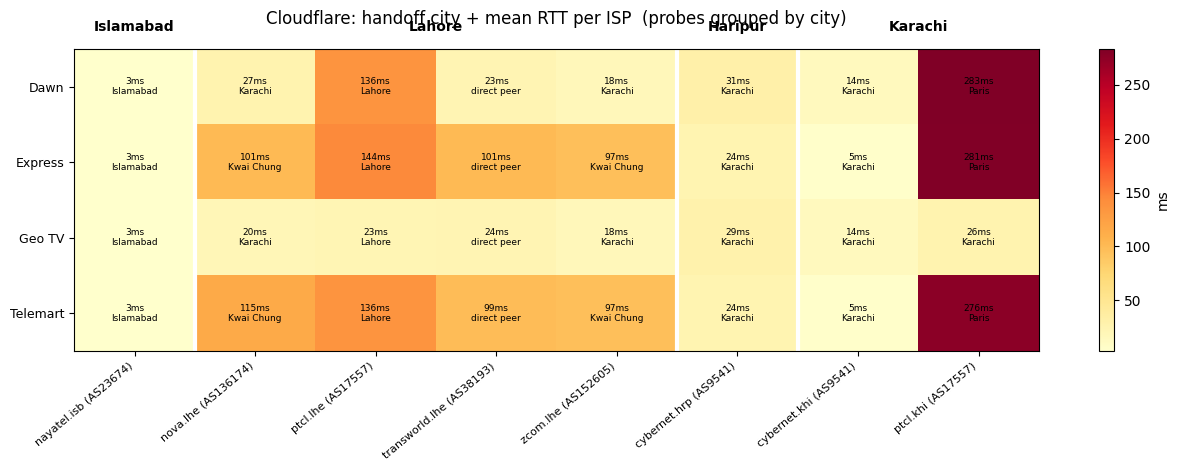

In [29]:
CF_ASN = 13335
cf = ok[ok['target_asn'] == CF_ASN].copy()
cf_sites = sorted(cf['target_label'].unique())
print('Cloudflare-fronted sites:', cf_sites)

def short_city(loc): return loc.split(',')[0] if isinstance(loc, str) else 'direct peer'
def _mode(s):
    m = s.mode(); return m.iloc[0] if len(m) else ''

rtt  = cf.pivot_table(index='target_label', columns='probe', values='dest_rtt_ms', aggfunc='mean').reindex(columns=PROBES)
city = (cf.assign(c=cf['dest_location'].map(short_city))
          .pivot_table(index='target_label', columns='probe', values='c', aggfunc=_mode).reindex(columns=PROBES))

fig, ax = plt.subplots(figsize=(13, 0.7 * len(cf_sites) + 2))
im = ax.imshow(rtt.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(rtt.columns))); ax.set_xticklabels(rtt.columns, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(len(rtt.index)));   ax.set_yticklabels(rtt.index, fontsize=9)
for i in range(rtt.shape[0]):
    for j in range(rtt.shape[1]):
        v = rtt.values[i, j]
        if pd.notna(v): ax.text(j, i, f'{v:.0f}ms\n{city.values[i, j]}', ha='center', va='center', fontsize=6.5)
codes = [PROBE_CC[p] for p in rtt.columns]; pos = 0
for code, grp in itertools.groupby(codes):
    n = len(list(grp))
    if pos > 0: ax.axvline(pos - 0.5, color='white', lw=3)
    ax.text(pos + n/2 - 0.5, -0.7, CITY_NAME[code], ha='center', va='bottom', fontsize=10, fontweight='bold')
    pos += n
ax.set_title('Cloudflare: handoff city + mean RTT per ISP  (probes grouped by city)', pad=18)
plt.colorbar(im, ax=ax, label='ms'); plt.tight_layout(); plt.show()

In [30]:
# who hands traffic into Cloudflare: the AS immediately before AS13335 in the path
AS_NAME = {17557: 'PTCL', 38193: 'Transworld', 9541: 'Cybernet', 23674: 'Nayatel',
           152605: 'Z-Com', 136174: 'Nova', 174: 'Cogent', 3356: 'Level3',
           6762: 'Sparkle', 3257: 'GTT', 1299: 'Arelion', 2914: 'NTT'}
PK_CITIES = ['Islamabad', 'Lahore', 'Karachi', 'Haripur', 'Rawalpindi']

def entry_as(path):
    if not isinstance(path, str): return None
    a = [x.strip() for x in path.split('>') if x.strip()]
    if str(CF_ASN) in a:
        i = a.index(str(CF_ASN)); return a[i-1] if i > 0 else 'direct'
    return a[-1] if a else None
def as_label(a):
    if a is None: return 'unknown'
    if a == 'direct': return 'direct peer'
    try: return AS_NAME.get(int(float(a)), f'AS{a}')
    except (ValueError, TypeError): return str(a)
cf['enters_via'] = cf['asns_in_path'].map(entry_as).map(as_label)

def local_pct(s):
    return round(100 * s.map(lambda x: isinstance(x, str) and any(c in x for c in PK_CITIES)).mean(), 0)

tab = (cf.groupby('probe')
         .agg(cf_rounds=('target_label', 'size'),
              mean_rtt_ms=('dest_rtt_ms', 'mean'),
              local_handoff_pct=('dest_location', local_pct),
              enters_via=('enters_via', lambda s: ', '.join(f'{k} ({v})' for k, v in s.value_counts().head(2).items())))
         .reindex(PROBES).round(1))
print('How each ISP reaches Cloudflare (entry AS = who hands off into AS13335;')
print('local_handoff_pct = share of rounds entering CF inside Pakistan):')
display(tab)

How each ISP reaches Cloudflare (entry AS = who hands off into AS13335;
local_handoff_pct = share of rounds entering CF inside Pakistan):


,cf_rounds,mean_rtt_ms,local_handoff_pct,enters_via
probe,,,,
nayatel.isb (AS23674),764,3.1,100.0,"Nayatel (763), direct peer (1)"
nova.lhe (AS136174),768,65.6,50.0,"Transworld (384), AS58453 (384)"
ptcl.lhe (AS17557),344,104.2,100.0,PTCL (344)
transworld.lhe (AS38193),768,61.6,0.0,direct peer (768)
zcom.lhe (AS152605),768,57.2,50.0,"AS58453 (384), Transworld (384)"
cybernet.hrp (AS9541),768,27.2,100.0,Cybernet (768)
cybernet.khi (AS9541),360,9.5,100.0,"Cybernet (341), direct peer (19)"
ptcl.khi (AS17557),760,216.5,25.0,"Level3 (570), PTCL (190)"


## 6. Diurnal: does latency rise in the evening?

Mean RTT by hour of day (PKT), holding one clean probe (`nayatel.isb`) fixed. Flat
lines across the shaded evening = **no congestion cycle**; the offshore cost is
structural.

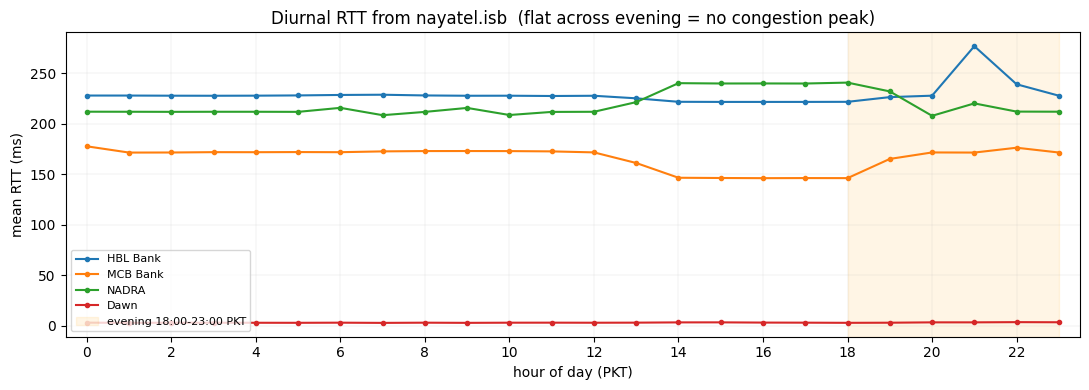

In [31]:
nay = ok[ok['probe'] == 'nayatel.isb (AS23674)']
fig, ax = plt.subplots(figsize=(11, 4))
for s in ['HBL Bank', 'MCB Bank', 'NADRA', 'Dawn']:
    h = nay[nay['target_label'] == s].groupby('hour')['dest_rtt_ms'].mean()
    ax.plot(h.index, h.values, marker='o', ms=3, label=s)
ax.axvspan(18, 23, color='orange', alpha=0.10, label='evening 18:00-23:00 PKT')
ax.set_xticks(range(0, 24, 2)); ax.set_xlim(-0.5, 23.5)
ax.set_xlabel('hour of day (PKT)'); ax.set_ylabel('mean RTT (ms)')
ax.set_title('Diurnal RTT from nayatel.isb  (flat across evening = no congestion peak)')
ax.legend(fontsize=8); ax.grid(True, lw=0.3, alpha=0.4)
plt.tight_layout(); plt.show()

## 7. Theoretical vs actual latency (the inflation cost)

Measured RTT vs the **physical floor** (fibre distance / speed of light in fibre, ~2/3 c).
The gap above the dashed line is the real-world overhead. Big overhead with a *nearby*
served_from city = a geo-mislabelled detour (e.g. PTCL 'served from Lahore' yet 300 ms).

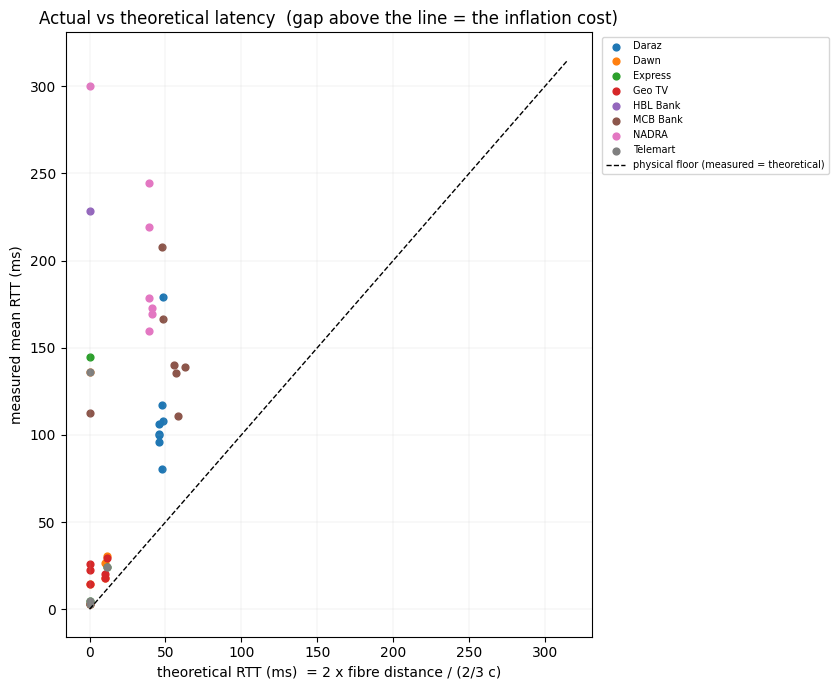

Biggest overhead above the physical floor (measured - theoretical):


,site,probe,served_from,km,theoretical_ms,measured_ms,overhead_ms
0,NADRA,ptcl.lhe (AS17557),Lahore,0,0.0,300.1,300.1
1,HBL Bank,ptcl.lhe (AS17557),Lahore,0,0.0,228.4,228.4
2,NADRA,ptcl.khi (AS17557),Gebze,3892,38.9,244.3,205.4
3,NADRA,nayatel.isb (AS23674),Gebze,3900,39.0,219.1,180.1
4,MCB Bank,ptcl.khi (AS17557),Singapore,4736,47.4,208.0,160.6
5,Express,ptcl.lhe (AS17557),Lahore,0,0.0,144.4,144.4
6,NADRA,cybernet.hrp (AS9541),Istanbul,3913,39.1,178.3,139.2
7,Telemart,ptcl.lhe (AS17557),Lahore,0,0.0,136.2,136.2
8,Dawn,ptcl.lhe (AS17557),Lahore,0,0.0,135.8,135.8
9,NADRA,nova.lhe (AS136174),Gebze,4112,41.1,173.0,131.9


In [32]:
rows = []
for (site, probe), g in ok.groupby(['target_label', 'probe']):
    mode = g['dest_location'].mode(); loc = mode.iloc[0] if len(mode) else None
    pc, dc = probe_coord(probe), coord_of(loc)
    if pc and dc:
        km = haversine_km(pc, dc)
        rows.append({'site': site, 'probe': probe, 'served_from': (loc.split(',')[0] if loc else loc),
                     'km': round(km), 'theoretical_ms': round(theo_rtt_ms(km), 1),
                     'measured_ms': round(g['dest_rtt_ms'].mean(), 1)})
T = pd.DataFrame(rows)
T['overhead_ms'] = (T['measured_ms'] - T['theoretical_ms']).round(1)

fig, ax = plt.subplots(figsize=(8.5, 7))
for site, s in T.groupby('site'):
    ax.scatter(s['theoretical_ms'], s['measured_ms'], s=24, label=site)
lim = max(T['theoretical_ms'].max(), T['measured_ms'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=1, label='physical floor (measured = theoretical)')
ax.set_xlabel('theoretical RTT (ms)  = 2 x fibre distance / (2/3 c)')
ax.set_ylabel('measured mean RTT (ms)')
ax.set_title('Actual vs theoretical latency  (gap above the line = the inflation cost)')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left'); ax.grid(True, lw=0.3, alpha=0.4)
plt.tight_layout(); plt.show()

print('Biggest overhead above the physical floor (measured - theoretical):')
display(T.sort_values('overhead_ms', ascending=False).head(12).reset_index(drop=True))

## 8. Same site, same ISP, two different cities

Cybernet and PTCL each have a probe in two cities, so holding the ISP fixed isolates the
effect of the **probe's city** (distance from the content).

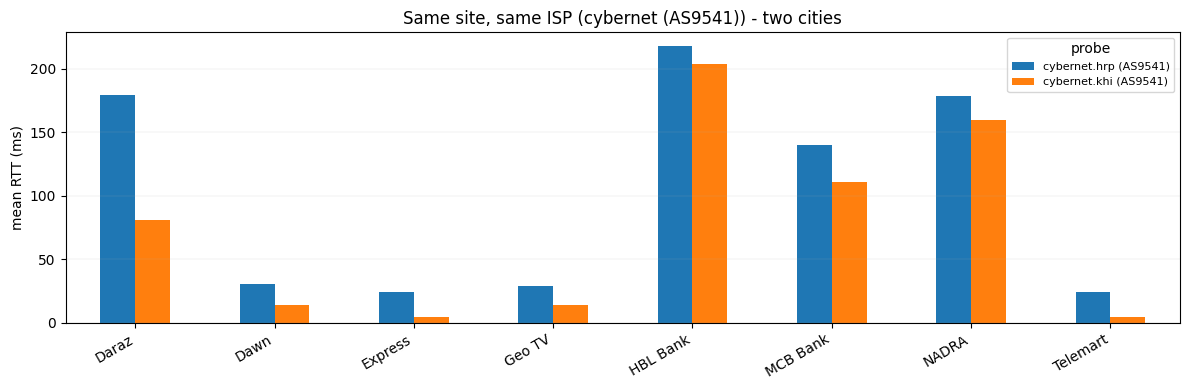

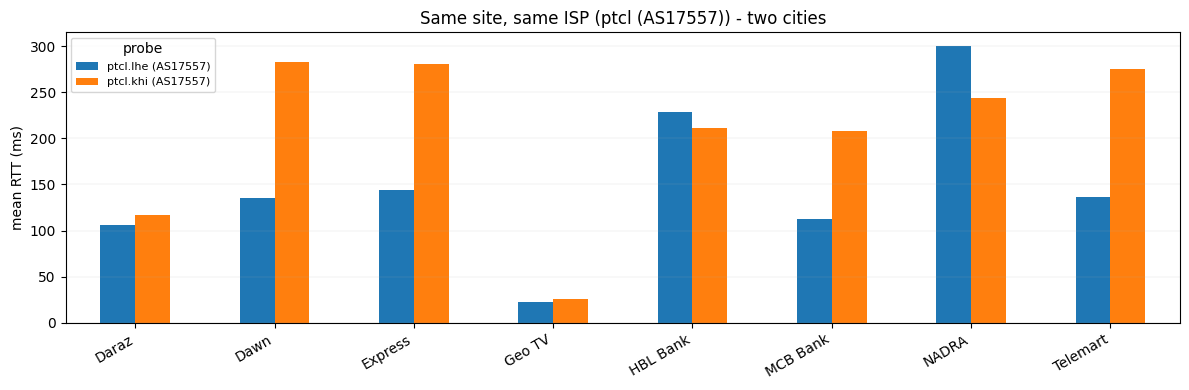

In [33]:
pairs = {
    'cybernet (AS9541)': ['cybernet.hrp (AS9541)', 'cybernet.khi (AS9541)'],
    'ptcl (AS17557)':    ['ptcl.lhe (AS17557)',    'ptcl.khi (AS17557)'],
}
for isp, (pa, pb) in pairs.items():
    m = (ok[ok['probe'].isin([pa, pb])]
         .groupby(['target_label', 'probe'])['dest_rtt_ms'].mean().unstack('probe')
         .reindex(columns=[pa, pb]).dropna(how='all'))
    ax = m.plot(kind='bar', figsize=(12, 4))
    ax.set_ylabel('mean RTT (ms)'); ax.set_xlabel('')
    ax.set_title(f'Same site, same ISP ({isp}) - two cities')
    ax.legend(fontsize=8, title='probe'); ax.grid(True, axis='y', lw=0.3, alpha=0.4)
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## 9. RTT distribution and jitter, same destination across probes

For HBL Bank (reachable from every probe): **jitter** (std dev of RTT) per probe, then
the **probability distribution** of RTT per probe. Uses the 1/5-min ping series. A tall
narrow distribution = steady; a wide / multi-peaked one = jittery.

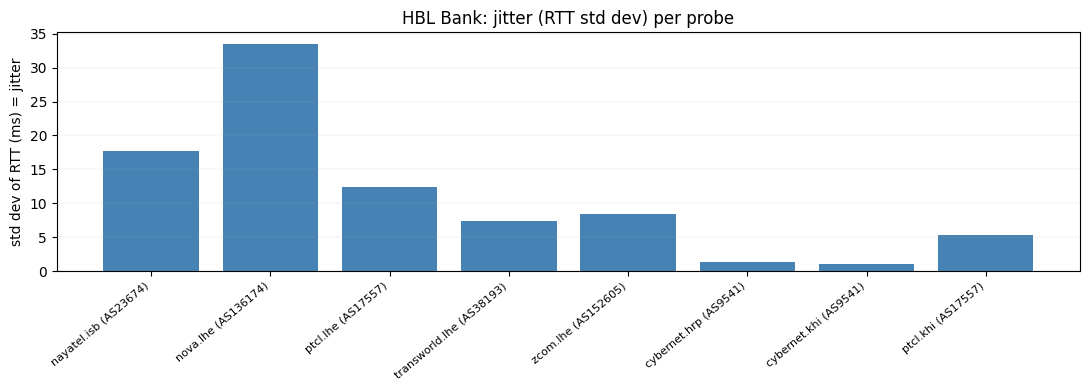

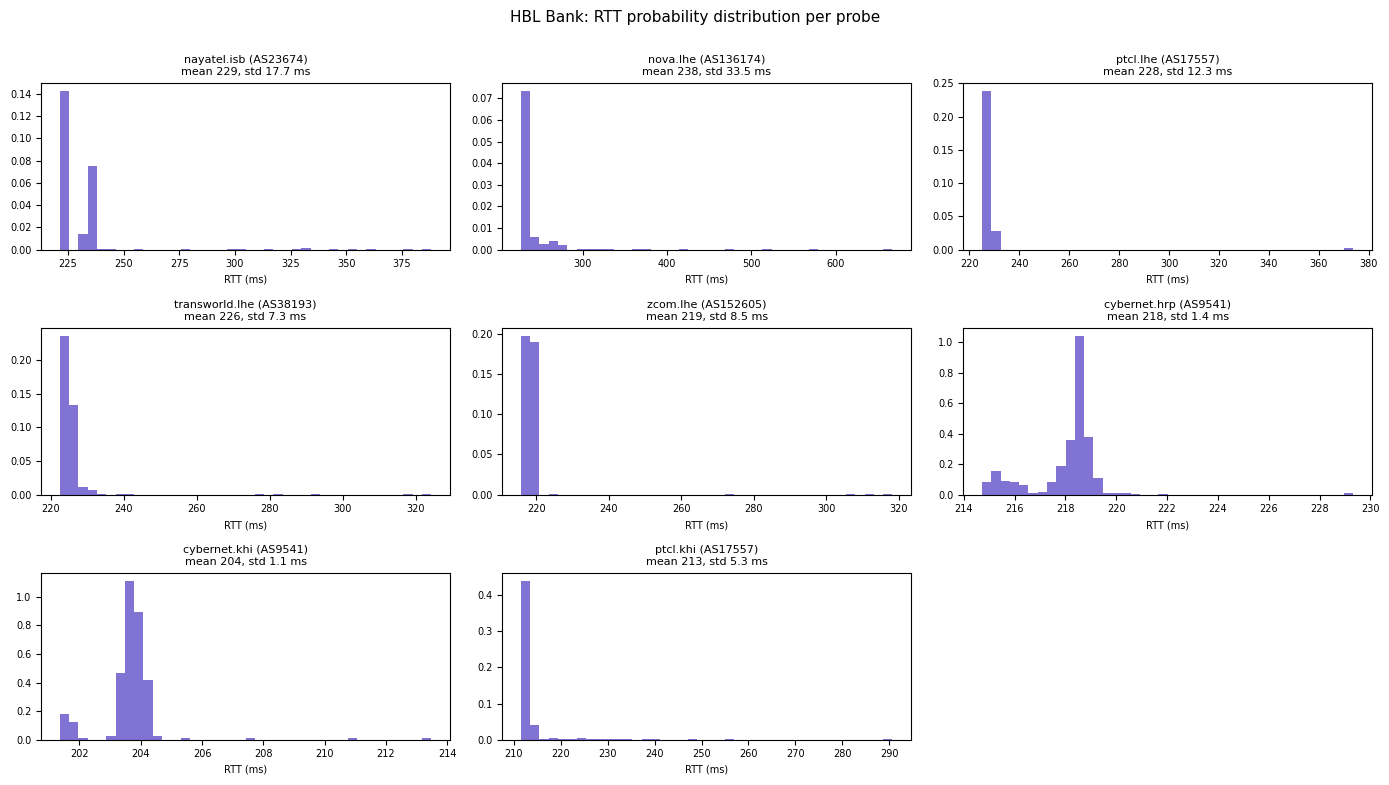

In [34]:
def dist_and_jitter(site):
    g = pg[pg['target_label'] == site].dropna(subset=['rtt_avg'])
    probes = [p for p in PROBES if p in set(g['probe'])]
    jit = g.groupby('probe')['rtt_avg'].std().reindex(probes)
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(range(len(jit)), jit.values, color='steelblue')
    ax.set_xticks(range(len(jit))); ax.set_xticklabels(jit.index, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('std dev of RTT (ms) = jitter')
    ax.set_title(f'{site}: jitter (RTT std dev) per probe'); ax.grid(True, axis='y', lw=0.3, alpha=0.4)
    plt.tight_layout(); plt.show()
    ncol = 3; nrow = (len(probes) + ncol - 1) // ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(14, 2.6 * nrow))
    for ax, p in zip(axes.flat, probes):
        v = g[g['probe'] == p]['rtt_avg']
        ax.hist(v, bins=40, density=True, color='slateblue', alpha=0.85)
        ax.set_title(f'{p}\nmean {v.mean():.0f}, std {v.std():.1f} ms', fontsize=8)
        ax.set_xlabel('RTT (ms)', fontsize=7); ax.tick_params(labelsize=7)
    for ax in axes.flat[len(probes):]: ax.axis('off')
    fig.suptitle(f'{site}: RTT probability distribution per probe', y=1.0, fontsize=11)
    plt.tight_layout(); plt.show()

dist_and_jitter('HBL Bank')

## 10. Tables: real path changes and probe ASN

Real changes have `distinct_metros > 1` (NADRA/MCB). The PTCL anchor's big `path_changes`
are last-hop flicker. The ASN table confirms every probe stayed on its registered
network all run.

In [35]:
rows = []
for (site, probe), g in df.sort_values('t').groupby(['target_label', 'probe']):
    p = g['asns_in_path'].dropna()
    ch = int((p.values[1:] != p.values[:-1]).sum()) if len(p) > 1 else 0
    metros = g['dest_location'].dropna().nunique()
    if ch > 0 or metros > 1:
        rows.append({'site': site, 'probe': probe, 'path_changes': ch, 'distinct_metros': metros})
pc = pd.DataFrame(rows).sort_values(['distinct_metros', 'path_changes'], ascending=False).reset_index(drop=True)
print('Top movers (real flips have distinct_metros > 1):'); display(pc.head(12))

if 'probe_asn_reg' in df.columns:
    a = [{'probe': p, 'measured_asn': sorted(g['probe_asn'].dropna().unique()),
          'registered_asn': sorted(g['probe_asn_reg'].dropna().unique()),
          'stable': sorted(g['probe_asn'].dropna().unique()) == sorted(g['probe_asn_reg'].dropna().unique())}
         for p, g in df.groupby('probe')]
    print('\nDynamic egress ASN (measured vs registered):'); display(pd.DataFrame(a))

Top movers (real flips have distinct_metros > 1):


,site,probe,path_changes,distinct_metros
0,NADRA,cybernet.hrp (AS9541),7,6
1,NADRA,ptcl.khi (AS17557),24,3
2,NADRA,cybernet.khi (AS9541),7,3
3,Dawn,cybernet.khi (AS9541),4,2
4,MCB Bank,zcom.lhe (AS152605),3,2
5,Geo TV,cybernet.khi (AS9541),2,2
6,MCB Bank,nayatel.isb (AS23674),2,2
7,MCB Bank,nova.lhe (AS136174),1,2
8,Dawn,cybernet.hrp (AS9541),0,2
9,Geo TV,cybernet.hrp (AS9541),0,2



Dynamic egress ASN (measured vs registered):


,probe,measured_asn,registered_asn,stable
0,cybernet.hrp (AS9541),[9541],[9541],True
1,cybernet.khi (AS9541),[9541],[9541],True
2,nayatel.isb (AS23674),[23674],[23674],True
3,nova.lhe (AS136174),[136174],[136174],True
4,ptcl.khi (AS17557),[17557],[17557],True
5,ptcl.lhe (AS17557),[17557],[17557],True
6,transworld.lhe (AS38193),[38193],[38193],True
7,zcom.lhe (AS152605),[152605],[152605],True
